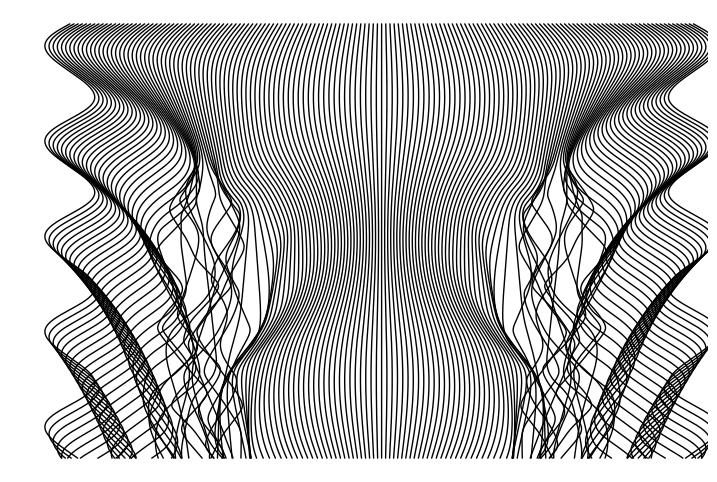

Saved SVG to 04_double_pendulum_columns_1.svg


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Physical params
# ==============================
G = 9.81
M1 = 1.0
M2 = 1.0
L1 = 1.0
L2 = 1.0
DAMP = 0.0000  # light viscous damping

# ==============================
# Simulation params
# ==============================
T_MAX = 4.0
DT = 0.002  # small step keeps tiny kicks small

# Sweep
N_COLS = 151  # odd so there is a center column if mode == "both"
KICK_RANGE = 8.0
# BASE_V = np.array([1.0, 1.6])  # [omega1, omega2] direction of kick
BASE_V = np.array([1.0, 1.0])    # [omega1, omega2] direction of kick

# Choose sweep direction: "both", "plus", or "minus"
SWEEP_MODE = "both"  # change to "both" or "minus" as needed

# Layout
FIGSIZE = (9, 6)
MARGIN_X = 0.05
MARGIN_Y = 0.03
COL_GAP = 0.00
LINE_WIDTH = 1.0
SAVE_SVG = True
SVG_PATH = "04_doublePendulum/04_double_pendulum_columns_1.svg"

# Scaling behavior
NORMALIZE_PER_COLUMN = False   # False uses a shared global symmetric scale
INNER_PAD = 0.00              # padding inside each column [0..1]

# Plot amplitude control (purely visual)
AMPLIFY = 12.0  # >1 exaggerates amplitude, <1 compresses it

# ==============================
# Dynamics
# ==============================
def derivs(state):
    th1, w1, th2, w2 = state
    m1, m2, l1, l2, g = M1, M2, L1, L2, G
    d = th2 - th1
    s, c = np.sin(d), np.cos(d)

    den1 = (m1 + m2) * l1 - m2 * l1 * c * c
    den2 = (l2 / l1) * den1

    num1 = (m2 * l1 * w1 * w1 * s * c
            + m2 * g * np.sin(th2) * c
            + m2 * l2 * w2 * w2 * s
            - (m1 + m2) * g * np.sin(th1))
    dw1 = num1 / den1

    num2 = (-m2 * l2 * w2 * w2 * s * c
            + (m1 + m2) * (g * np.sin(th1) * c - l1 * w1 * w1 * s - g * np.sin(th2)))
    dw2 = num2 / den2

    dw1 -= DAMP * w1
    dw2 -= DAMP * w2
    return np.array([w1, dw1, w2, dw2], float)

def rk4_step(state, dt):
    k1 = derivs(state)
    k2 = derivs(state + 0.5 * dt * k1)
    k3 = derivs(state + 0.5 * dt * k2)
    k4 = derivs(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate(theta1_0, omega1_0, theta2_0, omega2_0, t_max, dt):
    n = int(np.ceil(t_max / dt)) + 1
    th1 = np.empty(n)
    th2 = np.empty(n)
    state = np.array([theta1_0, omega1_0, theta2_0, omega2_0], float)
    for i in range(n):
        th1[i], _, th2[i], _ = state
        state = rk4_step(state, dt)
    return th1, th2

def x2_from_angles(th1, th2):
    return L1 * np.sin(th1) + L2 * np.sin(th2)

def build_sweep(mode: str, n_cols: int, k_range: float) -> np.ndarray:
    mode = mode.lower()
    if mode == "both":
        assert n_cols % 2 == 1, "N_COLS must be odd when SWEEP_MODE is 'both'."
        sweep = np.linspace(-k_range, k_range, n_cols)
        sweep[n_cols // 2] = 0.0
        return sweep
    if mode == "plus":
        # strictly positive range, exclude zero
        return np.linspace(k_range / n_cols, k_range, n_cols)
    if mode == "minus":
        # strictly negative range, exclude zero
        return np.linspace(-k_range, -k_range / n_cols, n_cols)
    raise ValueError("SWEEP_MODE must be 'both', 'plus', or 'minus'.")

# ==============================
# Build sweep and simulate
# ==============================
sweep = build_sweep(SWEEP_MODE, N_COLS, KICK_RANGE)

THETA1_INIT = 0.0
THETA2_INIT = 0.0

t = np.linspace(0.0, T_MAX, int(np.ceil(T_MAX / DT)) + 1)

# Run sims to collect x series for all columns
xs = []
for s in sweep:
    w1_0, w2_0 = (s * BASE_V).tolist()
    th1, th2 = simulate(THETA1_INIT, w1_0, THETA2_INIT, w2_0, T_MAX, DT)
    xs.append(x2_from_angles(th1, th2))
xs = np.array(xs)  # shape (N_COLS, N_time)

# ==============================
# Prepare symmetric normalization (no shifts)
# ==============================
# Apply visual amplification once, before computing scales
xs_amp = xs * AMPLIFY

if NORMALIZE_PER_COLUMN:
    # per-column symmetric scale factor
    scales = np.max(np.abs(xs_amp), axis=1)
    # avoid division by zero
    scales[scales < 1e-12] = 1.0
else:
    # single global symmetric scale
    global_scale = np.max(np.abs(xs_amp))
    if global_scale < 1e-12:
        global_scale = 1.0
    scales = np.full(xs_amp.shape[0], global_scale)

# ==============================
# Plot on a single axis
# ==============================
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axis("off")

xmin = MARGIN_X
xmax = 1.0 - MARGIN_X
ymin = MARGIN_Y
ymax = 1.0 - MARGIN_Y

total_gap = (N_COLS - 1) * COL_GAP
col_w = (xmax - xmin - total_gap) / N_COLS
y = ymin + (t / T_MAX) * (ymax - ymin)

for i in range(N_COLS):
    # Symmetric normalization around 0:
    # x_unit in [0,1] with 0.5 corresponding to x == 0
    x_unit = xs_amp[i] / (2.0 * scales[i]) + 0.5
    # optional inner padding
    x_norm = INNER_PAD + (1 - 2 * INNER_PAD) * x_unit

    x_left = xmin + i * (col_w + COL_GAP)
    x_plot = x_left + x_norm * col_w * AMPLIFY 
    ax.plot(x_plot, y, "k", lw=LINE_WIDTH, solid_joinstyle="round", solid_capstyle="round")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.invert_yaxis()

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved SVG to {SVG_PATH}")


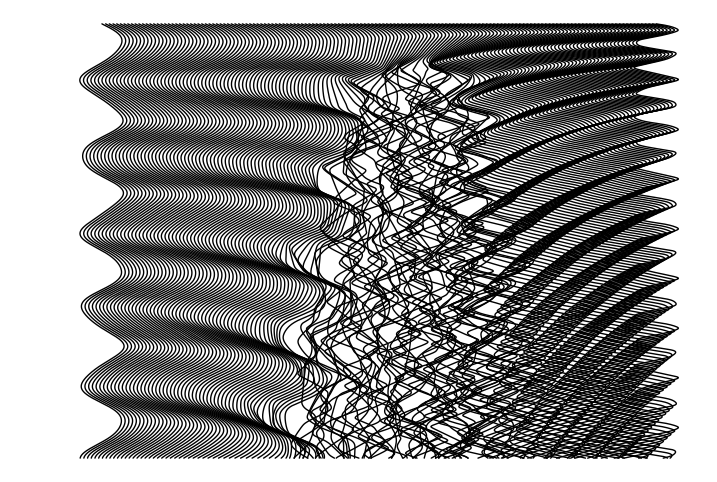

Saved SVG to 04_doublePendulum/04_double_pendulum_columns_2.svg


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Physical params
# ==============================
G = 9.81
M1 = 1.0
M2 = 1.0
L1 = 1.0
L2 = 1.0
DAMP = 0.0000  # light viscous damping

# ==============================
# Simulation params
# ==============================
T_MAX = 4.0
DT = 0.002  # small step keeps tiny kicks small

# Sweep
N_COLS = 151  # odd so there is a center column if mode == "both"
KICK_RANGE = 18.0
# BASE_V = np.array([1.0, 1.6])  # [omega1, omega2] direction of kick
BASE_V = np.array([0.0, 1.0])    # [omega1, omega2] direction of kick

# Choose sweep direction: "both", "plus", or "minus"
SWEEP_MODE = "plus"  # change to "both" or "minus" as needed

# Layout
FIGSIZE = (9, 6)
MARGIN_X = 0.10
MARGIN_Y = 0.03
COL_GAP = 0.00
LINE_WIDTH = 1.0
SAVE_SVG = True
SVG_PATH = "04_doublePendulum/04_double_pendulum_columns_2.svg"

# Scaling behavior
NORMALIZE_PER_COLUMN = True   # False uses a shared global symmetric scale
INNER_PAD = 0.00              # padding inside each column [0..1]

# Plot amplitude control (purely visual)
AMPLIFY = 12.0  # >1 exaggerates amplitude, <1 compresses it

# ==============================
# Dynamics
# ==============================
def derivs(state):
    th1, w1, th2, w2 = state
    m1, m2, l1, l2, g = M1, M2, L1, L2, G
    d = th2 - th1
    s, c = np.sin(d), np.cos(d)

    den1 = (m1 + m2) * l1 - m2 * l1 * c * c
    den2 = (l2 / l1) * den1

    num1 = (m2 * l1 * w1 * w1 * s * c
            + m2 * g * np.sin(th2) * c
            + m2 * l2 * w2 * w2 * s
            - (m1 + m2) * g * np.sin(th1))
    dw1 = num1 / den1

    num2 = (-m2 * l2 * w2 * w2 * s * c
            + (m1 + m2) * (g * np.sin(th1) * c - l1 * w1 * w1 * s - g * np.sin(th2)))
    dw2 = num2 / den2

    dw1 -= DAMP * w1
    dw2 -= DAMP * w2
    return np.array([w1, dw1, w2, dw2], float)

def rk4_step(state, dt):
    k1 = derivs(state)
    k2 = derivs(state + 0.5 * dt * k1)
    k3 = derivs(state + 0.5 * dt * k2)
    k4 = derivs(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate(theta1_0, omega1_0, theta2_0, omega2_0, t_max, dt):
    n = int(np.ceil(t_max / dt)) + 1
    th1 = np.empty(n)
    th2 = np.empty(n)
    state = np.array([theta1_0, omega1_0, theta2_0, omega2_0], float)
    for i in range(n):
        th1[i], _, th2[i], _ = state
        state = rk4_step(state, dt)
    return th1, th2

def x2_from_angles(th1, th2):
    return L1 * np.sin(th1) + L2 * np.sin(th2)

def build_sweep(mode: str, n_cols: int, k_range: float) -> np.ndarray:
    mode = mode.lower()
    if mode == "both":
        assert n_cols % 2 == 1, "N_COLS must be odd when SWEEP_MODE is 'both'."
        sweep = np.linspace(-k_range, k_range, n_cols)
        sweep[n_cols // 2] = 0.0
        return sweep
    if mode == "plus":
        # strictly positive range, exclude zero
        return np.linspace(k_range / n_cols, k_range, n_cols)
    if mode == "minus":
        # strictly negative range, exclude zero
        return np.linspace(-k_range, -k_range / n_cols, n_cols)
    raise ValueError("SWEEP_MODE must be 'both', 'plus', or 'minus'.")

# ==============================
# Build sweep and simulate
# ==============================
sweep = build_sweep(SWEEP_MODE, N_COLS, KICK_RANGE)

THETA1_INIT = 0.0
THETA2_INIT = 0.0

t = np.linspace(0.0, T_MAX, int(np.ceil(T_MAX / DT)) + 1)

# Run sims to collect x series for all columns
xs = []
for s in sweep:
    w1_0, w2_0 = (s * BASE_V).tolist()
    th1, th2 = simulate(THETA1_INIT, w1_0, THETA2_INIT, w2_0, T_MAX, DT)
    xs.append(x2_from_angles(th1, th2))
xs = np.array(xs)  # shape (N_COLS, N_time)

# ==============================
# Prepare symmetric normalization (no shifts)
# ==============================
# Apply visual amplification once, before computing scales
xs_amp = xs * AMPLIFY

if NORMALIZE_PER_COLUMN:
    # per-column symmetric scale factor
    scales = np.max(np.abs(xs_amp), axis=1)
    # avoid division by zero
    scales[scales < 1e-12] = 1.0
else:
    # single global symmetric scale
    global_scale = np.max(np.abs(xs_amp))
    if global_scale < 1e-12:
        global_scale = 1.0
    scales = np.full(xs_amp.shape[0], global_scale)

# ==============================
# Plot on a single axis
# ==============================
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axis("off")

xmin = MARGIN_X
xmax = 1.0 - MARGIN_X
ymin = MARGIN_Y
ymax = 1.0 - MARGIN_Y

total_gap = (N_COLS - 1) * COL_GAP
col_w = (xmax - xmin - total_gap) / N_COLS
y = ymin + (t / T_MAX) * (ymax - ymin)

for i in range(N_COLS):
    # Symmetric normalization around 0:
    # x_unit in [0,1] with 0.5 corresponding to x == 0
    x_unit = xs_amp[i] / (2.0 * scales[i]) + 0.5
    # optional inner padding
    x_norm = INNER_PAD + (1 - 2 * INNER_PAD) * x_unit

    x_left = xmin + i * (col_w + COL_GAP)
    x_plot = x_left + x_norm * col_w * AMPLIFY 
    ax.plot(x_plot, y, "k", lw=LINE_WIDTH, solid_joinstyle="round", solid_capstyle="round")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.invert_yaxis()

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved SVG to {SVG_PATH}")


# Strong damping

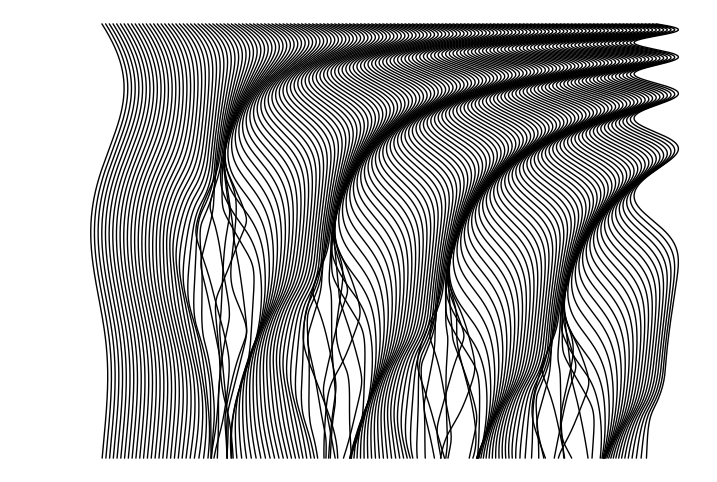

Saved SVG to 04_doublePendulum/04_double_pendulum_columns_damp.svg


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Physical params
# ==============================
G = 9.81
M1 = 1.0
M2 = 1.0
L1 = 1.0
L2 = 1.0
DAMP = 1.0  # light viscous damping

# ==============================
# Simulation params
# ==============================
T_MAX = 4.0
DT = 0.002  # small step keeps tiny kicks small

# Sweep
N_COLS = 151  # odd so there is a center column if mode == "both"
KICK_RANGE = 30.0
# BASE_V = np.array([1.0, 1.6])  # [omega1, omega2] direction of kick
BASE_V = np.array([1.0, 1.0])    # [omega1, omega2] direction of kick

# Choose sweep direction: "both", "plus", or "minus"
SWEEP_MODE = "plus"  # change to "both" or "minus" as needed

# Layout
FIGSIZE = (9, 6)
MARGIN_X = 0.10
MARGIN_Y = 0.03
COL_GAP = 0.00
LINE_WIDTH = 1.0
SAVE_SVG = True
SVG_PATH = "04_doublePendulum/04_double_pendulum_columns_damp.svg"

# Scaling behavior
NORMALIZE_PER_COLUMN = True   # False uses a shared global symmetric scale
INNER_PAD = 0.00              # padding inside each column [0..1]

# Plot amplitude control (purely visual)
AMPLIFY = 12.0  # >1 exaggerates amplitude, <1 compresses it

# ==============================
# Dynamics
# ==============================
def derivs(state):
    th1, w1, th2, w2 = state
    m1, m2, l1, l2, g = M1, M2, L1, L2, G
    d = th2 - th1
    s, c = np.sin(d), np.cos(d)

    den1 = (m1 + m2) * l1 - m2 * l1 * c * c
    den2 = (l2 / l1) * den1

    num1 = (m2 * l1 * w1 * w1 * s * c
            + m2 * g * np.sin(th2) * c
            + m2 * l2 * w2 * w2 * s
            - (m1 + m2) * g * np.sin(th1))
    dw1 = num1 / den1

    num2 = (-m2 * l2 * w2 * w2 * s * c
            + (m1 + m2) * (g * np.sin(th1) * c - l1 * w1 * w1 * s - g * np.sin(th2)))
    dw2 = num2 / den2

    dw1 -= DAMP * w1
    dw2 -= DAMP * w2
    return np.array([w1, dw1, w2, dw2], float)

def rk4_step(state, dt):
    k1 = derivs(state)
    k2 = derivs(state + 0.5 * dt * k1)
    k3 = derivs(state + 0.5 * dt * k2)
    k4 = derivs(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate(theta1_0, omega1_0, theta2_0, omega2_0, t_max, dt):
    n = int(np.ceil(t_max / dt)) + 1
    th1 = np.empty(n)
    th2 = np.empty(n)
    state = np.array([theta1_0, omega1_0, theta2_0, omega2_0], float)
    for i in range(n):
        th1[i], _, th2[i], _ = state
        state = rk4_step(state, dt)
    return th1, th2

def x2_from_angles(th1, th2):
    return L1 * np.sin(th1) + L2 * np.sin(th2)

def build_sweep(mode: str, n_cols: int, k_range: float) -> np.ndarray:
    mode = mode.lower()
    if mode == "both":
        assert n_cols % 2 == 1, "N_COLS must be odd when SWEEP_MODE is 'both'."
        sweep = np.linspace(-k_range, k_range, n_cols)
        sweep[n_cols // 2] = 0.0
        return sweep
    if mode == "plus":
        # strictly positive range, exclude zero
        return np.linspace(k_range / n_cols, k_range, n_cols)
    if mode == "minus":
        # strictly negative range, exclude zero
        return np.linspace(-k_range, -k_range / n_cols, n_cols)
    raise ValueError("SWEEP_MODE must be 'both', 'plus', or 'minus'.")

# ==============================
# Build sweep and simulate
# ==============================
sweep = build_sweep(SWEEP_MODE, N_COLS, KICK_RANGE)

THETA1_INIT = 0.0
THETA2_INIT = 0.0

t = np.linspace(0.0, T_MAX, int(np.ceil(T_MAX / DT)) + 1)

# Run sims to collect x series for all columns
xs = []
for s in sweep:
    w1_0, w2_0 = (s * BASE_V).tolist()
    th1, th2 = simulate(THETA1_INIT, w1_0, THETA2_INIT, w2_0, T_MAX, DT)
    xs.append(x2_from_angles(th1, th2))
xs = np.array(xs)  # shape (N_COLS, N_time)

# ==============================
# Prepare symmetric normalization (no shifts)
# ==============================
# Apply visual amplification once, before computing scales
xs_amp = xs * AMPLIFY

if NORMALIZE_PER_COLUMN:
    # per-column symmetric scale factor
    scales = np.max(np.abs(xs_amp), axis=1)
    # avoid division by zero
    scales[scales < 1e-12] = 1.0
else:
    # single global symmetric scale
    global_scale = np.max(np.abs(xs_amp))
    if global_scale < 1e-12:
        global_scale = 1.0
    scales = np.full(xs_amp.shape[0], global_scale)

# ==============================
# Plot on a single axis
# ==============================
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axis("off")

xmin = MARGIN_X
xmax = 1.0 - MARGIN_X
ymin = MARGIN_Y
ymax = 1.0 - MARGIN_Y

total_gap = (N_COLS - 1) * COL_GAP
col_w = (xmax - xmin - total_gap) / N_COLS
y = ymin + (t / T_MAX) * (ymax - ymin)

for i in range(N_COLS):
    # Symmetric normalization around 0:
    # x_unit in [0,1] with 0.5 corresponding to x == 0
    x_unit = xs_amp[i] / (2.0 * scales[i]) + 0.5
    # optional inner padding
    x_norm = INNER_PAD + (1 - 2 * INNER_PAD) * x_unit

    x_left = xmin + i * (col_w + COL_GAP)
    x_plot = x_left + x_norm * col_w * AMPLIFY 
    ax.plot(x_plot, y, "k", lw=LINE_WIDTH, solid_joinstyle="round", solid_capstyle="round")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.invert_yaxis()

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved SVG to {SVG_PATH}")


# Phase depiction

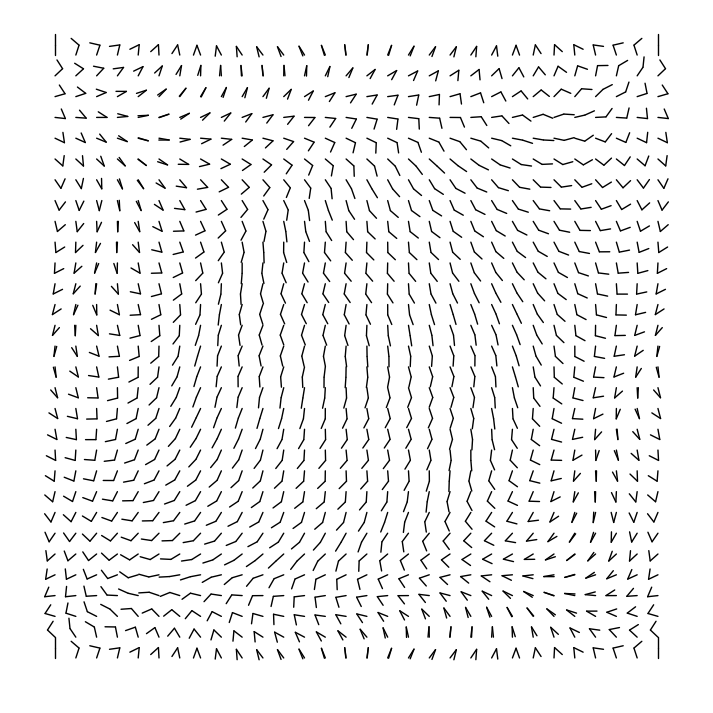

Saved SVG to 04_doublePendulum/05_phasegrid_theta_init.svg


In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Physical params
# ==============================
G = 9.81
M1 = 1.0
M2 = 1.0
L1 = 1.0
L2 = 1.0
DAMP = 0.0000  # light viscous damping

# ==============================
# Simulation params
# ==============================
DT = 0.002
T_EVAL = 0.5          # seconds to simulate before sampling the state
N_GRID = 30           # number of cells per axis for initial angles
W1_INIT = 0.0         # initial angular velocity of segment 1
W2_INIT = 0.0         # initial angular velocity of segment 2

# Layout
FIGSIZE = (9, 9)
MARGIN_X = 0.05
MARGIN_Y = 0.05
SAVE_SVG = True
SVG_PATH = "04_doublePendulum/05_phasegrid_theta_init.svg"

# Drawing
BASE_LW = 1         # line width for first segment
TIP_LW  = 1         # line width for second segment
CELL_SCALE = 1.0

# ==============================
# Dynamics
# ==============================
def derivs(state):
    th1, w1, th2, w2 = state
    m1, m2, l1, l2, g = M1, M2, L1, L2, G
    d = th2 - th1
    s, c = np.sin(d), np.cos(d)

    den1 = (m1 + m2) * l1 - m2 * l1 * c * c
    den2 = (l2 / l1) * den1

    num1 = (m2 * l1 * w1 * w1 * s * c
            + m2 * g * np.sin(th2) * c
            + m2 * l2 * w2 * w2 * s
            - (m1 + m2) * g * np.sin(th1))
    dw1 = num1 / den1

    num2 = (-m2 * l2 * w2 * w2 * s * c
            + (m1 + m2) * (g * np.sin(th1) * c - l1 * w1 * w1 * s - g * np.sin(th2)))
    dw2 = num2 / den2

    dw1 -= DAMP * w1
    dw2 -= DAMP * w2
    return np.array([w1, dw1, w2, dw2], float)

def rk4_step(state, dt):
    k1 = derivs(state)
    k2 = derivs(state + 0.5 * dt * k1)
    k3 = derivs(state + 0.5 * dt * k2)
    k4 = derivs(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate(theta1_0, omega1_0, theta2_0, omega2_0, t_eval, dt):
    n = int(np.ceil(t_eval / dt))
    state = np.array([theta1_0, omega1_0, theta2_0, omega2_0], float)
    for _ in range(n):
        state = rk4_step(state, dt)
    return state  # [th1, w1, th2, w2] at t_eval

# ==============================
# Build angle grid and simulate
# ==============================
theta1_vals = np.linspace(-np.pi, np.pi, N_GRID)
theta2_vals = np.linspace(-np.pi, np.pi, N_GRID)

# Precompute plotting scale so links fit in each cell
# We place the pivot at the center of each cell and scale lengths to 45% of the smaller cell dimension.
xmin, xmax = MARGIN_X, 1.0 - MARGIN_X
ymin, ymax = MARGIN_Y, 1.0 - MARGIN_Y
cell_w = (xmax - xmin) / N_GRID
cell_h = (ymax - ymin) / N_GRID
cell_scale = CELL_SCALE * min(cell_w, cell_h)
total_len = L1 + L2
l1p = cell_scale * (L1 / total_len)
l2p = cell_scale * (L2 / total_len)

# ==============================
# Plot grid of final configurations
# ==============================
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axis("off")

for i, th1_0 in enumerate(theta1_vals):
    for j, th2_0 in enumerate(theta2_vals):
        th1_f, w1_f, th2_f, w2_f = simulate(th1_0, W1_INIT, th2_0, W2_INIT, T_EVAL, DT)

        # Pivot at center of the cell
        cx = xmin + (j + 0.5) * cell_w
        cy = ymin + (i + 0.5) * cell_h

        # First joint
        x1 = cx + l1p * np.sin(th1_f)
        y1 = cy - l1p * np.cos(th1_f)

        # End effector
        x2 = x1 + l2p * np.sin(th2_f)
        y2 = y1 - l2p * np.cos(th2_f)

        # Draw segments
        ax.plot([cx, x1], [cy, y1], "k", lw=BASE_LW, solid_capstyle="round")
        ax.plot([x1, x2], [y1, y2], "k", lw=TIP_LW,  solid_capstyle="round")

# Keep coordinates normalized to [0,1]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved SVG to {SVG_PATH}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Physical params
# ==============================
G = 9.81
M1 = 1.0
M2 = 1.0
L1 = 1.0
L2 = 1.0
DAMP = 0.0  # light viscous damping

# ==============================
# Simulation params
# ==============================
DT = 0.002
T_EVAL = 10          # seconds to simulate and draw trajectory
N_GRID = 10           # number of cells per axis for initial angles
W1_INIT = 0.0         # initial angular velocity of segment 1
W2_INIT = 0.0         # initial angular velocity of segment 2

# Layout
FIGSIZE = (9, 9)
MARGIN_X = 0.05
MARGIN_Y = 0.05
SAVE_SVG = True
SVG_PATH = "04_doublePendulum/05_phasegrid_tip_trajectories.svg"

# Drawing
TRAJ_LW = 0.6         # line width for tip trajectory
CELL_SCALE = 0.55     # scales link lengths relative to cell size
nudge = 0.9999

# ==============================
# Dynamics
# ==============================
def derivs(state):
    th1, w1, th2, w2 = state
    m1, m2, l1, l2, g = M1, M2, L1, L2, G
    d = th2 - th1
    s, c = np.sin(d), np.cos(d)

    den1 = (m1 + m2) * l1 - m2 * l1 * c * c
    den2 = (l2 / l1) * den1

    num1 = (m2 * l1 * w1 * w1 * s * c
            + m2 * g * np.sin(th2) * c
            + m2 * l2 * w2 * w2 * s
            - (m1 + m2) * g * np.sin(th1))
    dw1 = num1 / den1

    num2 = (-m2 * l2 * w2 * w2 * s * c
            + (m1 + m2) * (g * np.sin(th1) * c - l1 * w1 * w1 * s - g * np.sin(th2)))
    dw2 = num2 / den2

    dw1 -= DAMP * w1
    dw2 -= DAMP * w2
    return np.array([w1, dw1, w2, dw2], float)

def rk4_step(state, dt):
    k1 = derivs(state)
    k2 = derivs(state + 0.5 * dt * k1)
    k3 = derivs(state + 0.5 * dt * k2)
    k4 = derivs(state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate_trajectory(theta1_0, omega1_0, theta2_0, omega2_0, t_eval, dt):
    n = int(np.ceil(t_eval / dt)) + 1
    th1 = np.empty(n)
    th2 = np.empty(n)
    state = np.array([theta1_0, omega1_0, theta2_0, omega2_0], float)
    for i in range(n):
        th1[i], _, th2[i], _ = state
        state = rk4_step(state, dt)
    return th1, th2  # arrays over time

# ==============================
# Build angle grid
# ==============================
theta1_vals = np.linspace(-nudge*np.pi, nudge*np.pi, N_GRID)
theta2_vals = np.linspace(-nudge*np.pi, nudge*np.pi, N_GRID)

# ==============================
# Cell geometry and link scaling
# ==============================
xmin, xmax = MARGIN_X, 1.0 - MARGIN_X
ymin, ymax = MARGIN_Y, 1.0 - MARGIN_Y
cell_w = (xmax - xmin) / N_GRID
cell_h = (ymax - ymin) / N_GRID

# Scale link lengths to fit nicely in a cell
total_len = L1 + L2
cell_scale = CELL_SCALE * 0.9 * min(cell_w, cell_h)  # 0.9 for a bit of margin
l1p = cell_scale * (L1 / total_len)
l2p = cell_scale * (L2 / total_len)

# ==============================
# Plot trajectories per cell
# ==============================
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.axis("off")

for i, th1_0 in enumerate(theta1_vals):
    for j, th2_0 in enumerate(theta2_vals):
        th1_t, th2_t = simulate_trajectory(th1_0, W1_INIT, th2_0, W2_INIT, T_EVAL, DT)

        # Pivot at center of the cell
        cx = xmin + (j + 0.5) * cell_w
        cy = ymin + (i + 0.5) * cell_h

        # Tip coordinates over time using scaled link lengths
        x1_t = cx + l1p * np.sin(th1_t)
        y1_t = cy - l1p * np.cos(th1_t)
        x2_t = x1_t + l2p * np.sin(th2_t)
        y2_t = y1_t - l2p * np.cos(th2_t)

        # Optional downsampling if you want fewer segments per polyline
        # step = 1  # increase to 2,3,... to thin lines
        # ax.plot(x2_t[::step], y2_t[::step], "k", lw=TRAJ_LW, solid_capstyle="round")
        ax.plot(x2_t, y2_t, "k", lw=TRAJ_LW, solid_capstyle="round")

# Keep coordinates normalized to [0,1]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Saved SVG to {SVG_PATH}")
